# NASA IMS Bearing Dataset — Frequency Domain Analysis
Time domain features tell us *how much* a bearing is vibrating.
Frequency domain analysis tells us *why*, by revealing which frequencies 
carry the most energy and how the spectrum changes as damage develops.

This is done using the **Fast Fourier Transform (FFT)**, which decomposes 
a vibration signal into its constituent frequencies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR = Path("../data/1st_test")
BEARINGS = ["bearing_1", "bearing_2", "bearing_3", "bearing_4"]
SAMPLING_RATE = 20480  # Hz

## What is the FFT?
A raw vibration signal shows amplitude over time. The FFT transforms it into 
amplitude over frequency, called the **frequency spectrum**. 

Each peak in the spectrum corresponds to a repeating event at that frequency.
A bearing defect on the outer race, for example, produces impacts at a 
predictable frequency called the **Ball Pass Frequency Outer race (BPFO)**.
By watching specific frequencies grow over time, we can identify the exact 
type and location of a developing fault.

In [2]:
def load_file(filepath):
    df = pd.read_csv(
        filepath, sep="\t", header=None,
        names=BEARINGS
    )
    return df

def compute_fft(signal, sampling_rate):
    n = len(signal)
    # Compute FFT and take only positive frequencies
    fft_vals = np.abs(np.fft.rfft(signal)) / n
    fft_freqs = np.fft.rfftfreq(n, d=1/sampling_rate)
    return fft_freqs, fft_vals

files = sorted([f for f in DATA_DIR.iterdir() if f.is_file()])
print(f"Total files: {len(files)}")
print(f"First file: {files[0].name}")
print(f"Last file:  {files[-1].name}")

Total files: 2156
First file: 2003.10.22.12.06.24
Last file:  2003.11.25.23.39.56


## Frequency Spectrum — Early vs Late
We compare the frequency spectrum of Bearing 3 at three points:
- **Early:** start of the test (healthy)
- **Middle:** midpoint of the test
- **Late:** near the end (failure)

A healthy bearing has a flat, low energy spectrum.
A failing one shows prominent peaks at specific fault frequencies.

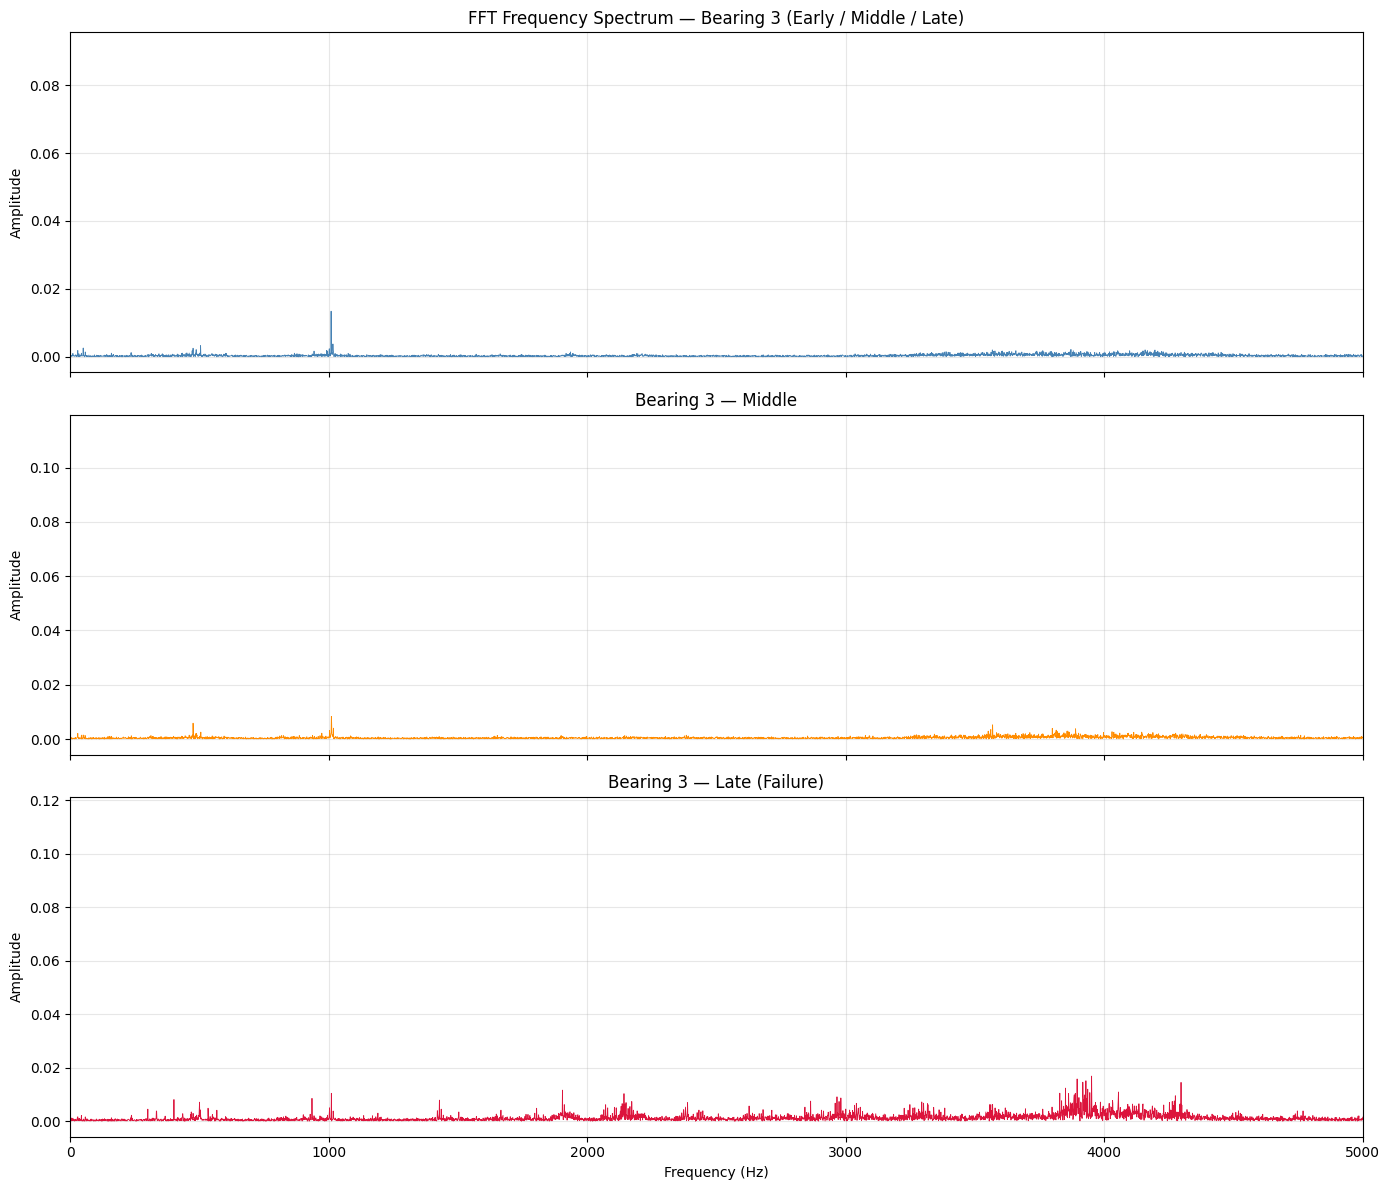

In [3]:
early  = files[0]
middle = files[len(files) // 2]
late   = files[-1]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, file, label, color in zip(
    axes,
    [early, middle, late],
    ["Early (Healthy)", "Middle", "Late (Failure)"],
    ["steelblue", "darkorange", "crimson"]
):
    df = load_file(file)
    signal = df["bearing_3"].values
    freqs, amps = compute_fft(signal, SAMPLING_RATE)

    ax.plot(freqs, amps, linewidth=0.6, color=color)
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Bearing 3 — {label}")
    ax.set_xlim(0, 5000)  # Focus on 0–5000 Hz range

axes[0].set_title("FFT Frequency Spectrum — Bearing 3 (Early / Middle / Late)")
axes[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.savefig("../outputs/figures/04_fft_comparison.png", dpi=150)
plt.show()

## Spectral Energy Over Time
Instead of looking at individual snapshots, we track how total spectral energy 
evolves across the full test for all bearings.
This gives a continuous view of frequency domain degradation.

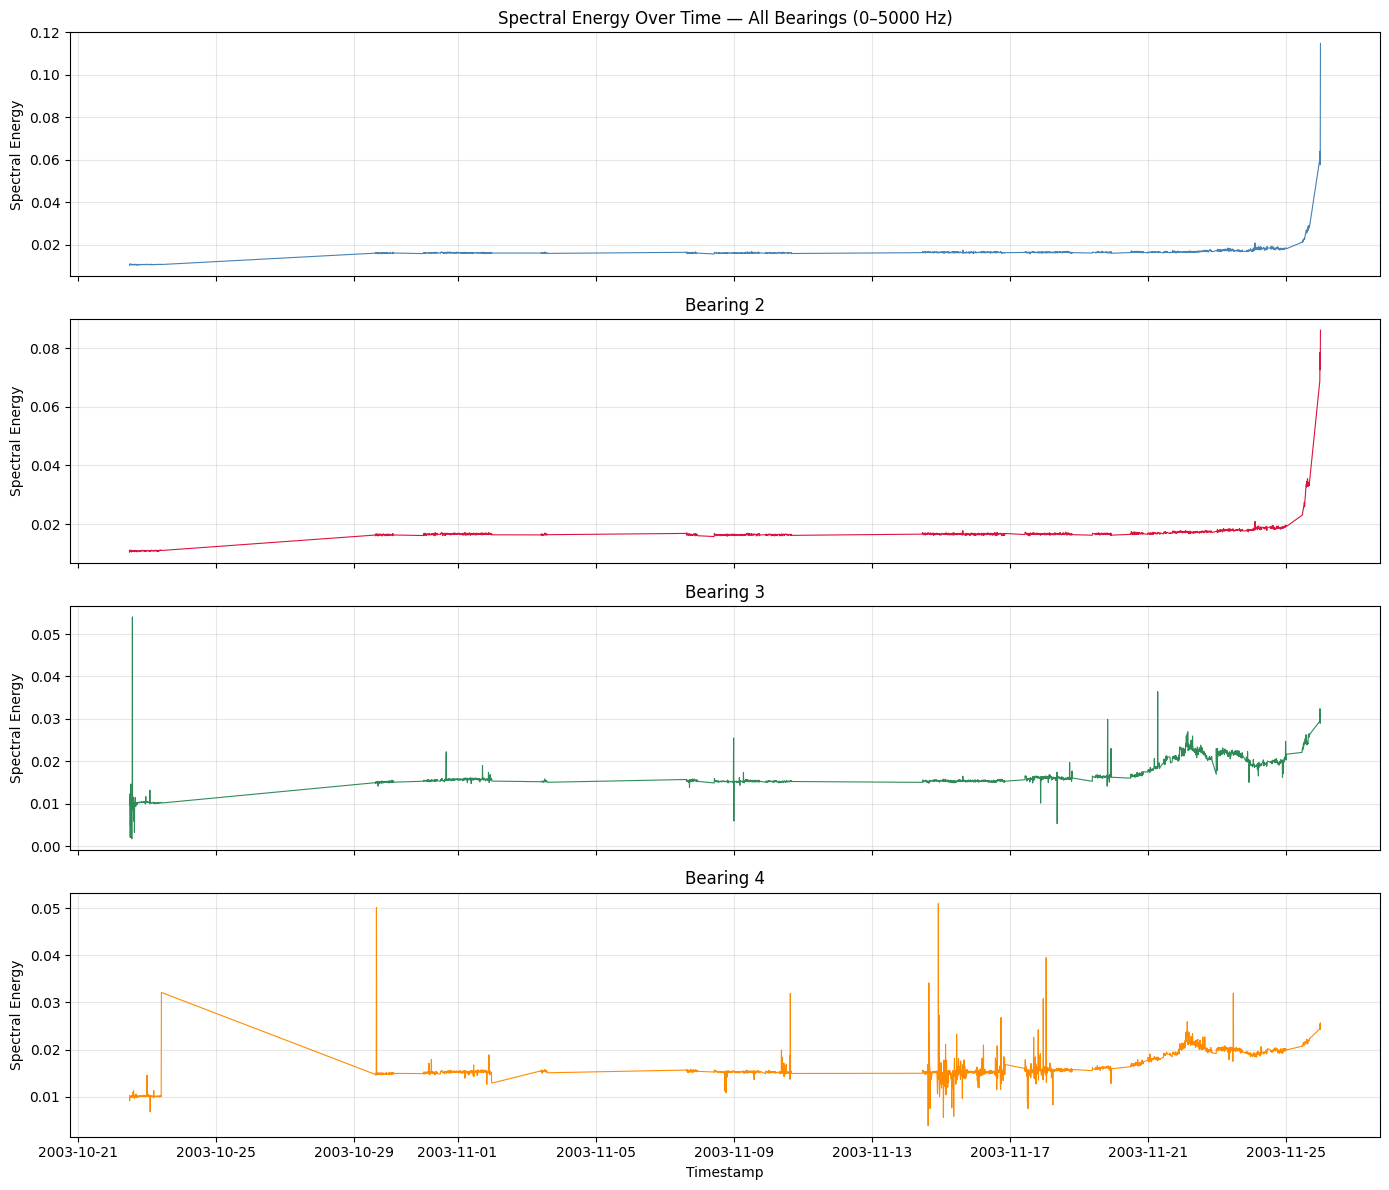

In [4]:
def compute_spectral_energy(data_dir, bearing, freq_min=0, freq_max=5000):
    files = sorted([f for f in data_dir.iterdir() if f.is_file()])
    timestamps = []
    energies = []

    for file in files:
        parts = file.name.split(".")
        timestamp = pd.Timestamp(
            year=int(parts[0]), month=int(parts[1]), day=int(parts[2]),
            hour=int(parts[3]), minute=int(parts[4]), second=int(parts[5])
        )

        df = pd.read_csv(file, sep="\t", header=None, names=BEARINGS)
        signal = df[bearing].values
        freqs, amps = compute_fft(signal, SAMPLING_RATE)

        # Sum energy within frequency band
        mask = (freqs >= freq_min) & (freqs <= freq_max)
        energy = np.sum(amps[mask] ** 2)

        timestamps.append(timestamp)
        energies.append(energy)

    return pd.Series(energies, index=timestamps)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
colors = ["steelblue", "crimson", "seagreen", "darkorange"]

for ax, bearing, color in zip(axes, BEARINGS, colors):
    energy = compute_spectral_energy(DATA_DIR, bearing)
    ax.plot(energy.index, energy.values, linewidth=0.8, color=color)
    ax.set_ylabel("Spectral Energy")
    ax.set_title(bearing.replace("_", " ").title())

axes[0].set_title("Spectral Energy Over Time — All Bearings (0–5000 Hz)")
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.savefig("../outputs/figures/04_spectral_energy_over_time.png", dpi=150)
plt.show()

## Key Findings
- The frequency spectrum of Bearing 3 changes dramatically from early to late stage,
  energy that was spread evenly across frequencies concentrates into sharp peaks near failure
- Spectral energy tracks closely with RMS from the time domain,  confirming both 
  methods capture the same underlying physical degradation
- Frequency domain analysis adds interpretability: specific peaks can be matched 
  to known bearing fault frequencies (BPFO, BPFI, BSF) to identify fault location
  
## Next Steps
This EDA lays the groundwork for a machine learning model that uses these 
time and frequency domain features to predict bearing failure before it occurs.